# Descrição do Notebook

Neste notebook fizemos o carregamento dos dados do banco de dados na nuvem da Oracle, fizemos uma breve análise e preparação dos dados para treinar um modelo baseline utilizando ARIMA. Após a avaliação do ARIMA, fizemos uma ponderação sobre outros modelos e testamos o Prophet com resultados interessantes, mas não suficientes para o objetivo do projeto. Outros modelos foram testados no notebook [XGBoost_KMeans.ipynb](XGBoost_KMeans.ipynb).

In [ ]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import oracledb
import pandas as pd
from dotenv import load_dotenv
from prophet import Prophet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

load_dotenv()
warnings.filterwarnings('ignore')

c:\Users\vitor\Data_Projects\EC2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
CONNECT_STRING = '(description= (retry_count=20)(retry_delay=3)(address=(protocol=tcps)(port=1522)(host=adb.sa-saopaulo-1.oraclecloud.com))(connect_data=(service_name=g253a13c6f2211a_dadosaiopslocaweb_low.adb.oraclecloud.com))(security=(ssl_server_dn_match=yes)))'

def conectar_oracle():
    return oracledb.connect(
        user=DB_USER,
        password=DB_PASSWORD,
        dsn=CONNECT_STRING,
        wallet_location=r"C:/opt/OracleCloud/Wallet_dadosAIOpsLocaweb",
        wallet_password=DB_PASSWORD
    )

In [ ]:
# Lendo dados de uma view do banco de dados oracle
df = pd.read_sql_query("SELECT * FROM admin.VIEW_INCIDENTES_P2_P3", con=conectar_oracle()) # pyright: ignore[reportArgumentType]

In [4]:
df.shape

(57381, 18)

In [5]:
df.sample(50)

,TP_PRIORIDADE,NM_PRODUTO,NM_CATEGORIA,NM_SUBCATEGORIA,NM_GRUPO_DESIGNADO,NM_ITEM_CONFIGURACAO,DT_ABERTO,DT_RESOLVIDO,DT_ENCERRADO,NR_DURACAO,CD_FECHAMENTO,DS_RESUMIDA,TP_SOLUCAO,TP_ABERTO_POR,CD_INCIDENTE_PAI,TP_STATUS,FL_KPI,FL_KPI_VIOLADO
21076,2 - Alta,lhvp,cat73,sub420,Team14,IC03767,2025-10-28 15:12:56,NaT,2025-10-28 15:18:11,315,Em andamento,Problem: Unavailable by ICMP ping,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
22227,2 - Alta,Nao Informado,Nao Informado,Nao Informado,Team14,IC00930,2025-10-22 23:40:12,NaT,2025-10-23 00:29:13,2941,Em andamento,Problem: Namespace: produtos-hosting-dns-priva...,Nenhuma,Monitoramento,INC8577243,Sem Intervenção,NAO,NAO
34910,3 - Média,Nao Informado,cat49,sub412,Team03,IC02802,2025-08-18 11:48:31,2025-08-18 15:36:53,2025-08-23 01:01:02,13702,Outro,Problem: Free space in BLZ1_ESXIALLIN_38 is le...,Nenhuma,Monitoramento,NaN,Encerrado Automaticamente,NAO,NAO
52783,3 - Média,lcsi,cat41,sub160,Team14,IC00725,2025-01-10 09:28:54,2025-01-10 11:30:06,2025-01-10 12:06:59,7272,Falha de Aplicação,Erro 404 - conectagestaodeprojetosIC04172comIC...,Nenhuma,Manual,NaN,Encerrado,SIM,NAO
33983,3 - Média,lhco,cat71,sub427,Team14,IC00451,2025-08-19 21:19:02,2025-08-20 03:55:49,2025-08-25 01:00:22,23807,Falha causada pelo cliente,Problem: Free Disk Space is less than 10% on v...,Definitiva,Monitoramento,NaN,Encerrado Automaticamente,SIM,NAO
32236,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team12,IC02990,2025-09-08 05:25:18,NaT,2025-09-08 05:37:00,702,Em andamento,Problem: Interface Ethernet1/27: High bandwidt...,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
11370,3 - Média,lhvp,cat87,sub296,Team11,IC01254,2025-12-01 14:39:53,2025-12-01 15:23:46,2025-12-01 15:36:22,2633,Falha de Aplicação,AEP-IC02984 erro IC00744,Contorno,Manual,NaN,Encerrado,SIM,NAO
17500,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team14,IC00134,2025-11-12 08:57:48,NaT,2025-11-12 10:17:58,4810,Em andamento,Problem: Apache Busy Workers,Nenhuma,Monitoramento,INC8598348,Sem Intervenção,NAO,NAO
575,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team14,IC00236,2025-12-30 17:27:43,NaT,2025-12-30 17:51:41,1438,Em andamento,Problem: Disk I/O is overloaded on IC00236,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO
12418,3 - Média,Nao Informado,Nao Informado,Nao Informado,Team14,IC00099,2025-11-24 16:13:50,NaT,2025-11-24 16:34:48,1258,Em andamento,Problem: Check HTTP Port is Down,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,NAO


In [6]:
# Verificando período da base de dados
print(df['DT_ABERTO'].min())
print("\n",df['DT_ABERTO'].max())

2023-01-02 20:19:58

 2025-12-31 23:45:18


In [7]:
# Criando uma cópia do DataFrame original para manipulação
df2 = df.copy()

In [8]:
df2.dtypes

TP_PRIORIDADE                      str
NM_PRODUTO                         str
NM_CATEGORIA                       str
NM_SUBCATEGORIA                    str
NM_GRUPO_DESIGNADO                 str
NM_ITEM_CONFIGURACAO               str
DT_ABERTO               datetime64[us]
DT_RESOLVIDO            datetime64[us]
DT_ENCERRADO            datetime64[us]
NR_DURACAO                       int64
CD_FECHAMENTO                      str
DS_RESUMIDA                        str
TP_SOLUCAO                         str
TP_ABERTO_POR                      str
CD_INCIDENTE_PAI                   str
TP_STATUS                          str
FL_KPI                             str
FL_KPI_VIOLADO                     str
dtype: object

In [9]:
# Transformando de char para numérico a coluna de prioridade, para facilitar a análise

mudanca_prioridade = {
    "2 - Alta": 2,
    "3 - Média": 3,    
}

df2["TP_PRIORIDADE"] = df["TP_PRIORIDADE"].map(mudanca_prioridade)
df2["TP_PRIORIDADE"].value_counts()

TP_PRIORIDADE
3    41732
2    15649
Name: count, dtype: int64

In [10]:
df2["FL_KPI_VIOLADO"].value_counts()

FL_KPI_VIOLADO
NAO    52873
SIM     4508
Name: count, dtype: int64

In [11]:
# Verificando os incidentes que violaram o KPI
df2[df2["FL_KPI_VIOLADO"] == "SIM"]

,TP_PRIORIDADE,NM_PRODUTO,NM_CATEGORIA,NM_SUBCATEGORIA,NM_GRUPO_DESIGNADO,NM_ITEM_CONFIGURACAO,DT_ABERTO,DT_RESOLVIDO,DT_ENCERRADO,NR_DURACAO,CD_FECHAMENTO,DS_RESUMIDA,TP_SOLUCAO,TP_ABERTO_POR,CD_INCIDENTE_PAI,TP_STATUS,FL_KPI,FL_KPI_VIOLADO
117,2,lsd0,cat85,sub307,Team14,IC00090,2025-12-31 08:31:17,2025-12-31 14:38:40,2025-12-31 14:43:02,22043,Falha de Cloud,[vps57635] POOL Fora do ar - IC00166,Contorno,Manual,INC8653593,Encerrado,NAO,SIM
334,2,lsin,cat141,sub446,Team03,IC00166,2025-12-31 04:19:30,2025-12-31 14:16:11,2025-12-31 14:44:14,35801,Falha de Hardware,Problem: Unavailable by ICMP ping,Definitiva,Monitoramento,NaN,Encerrado,SIM,SIM
652,3,lsmt,cat46,sub31,Team05,IC00277,2025-12-30 06:42:20,NaT,2025-12-31 11:11:34,102554,Em andamento,Problem: Check PMTA IC00622 Queue,Nenhuma,Monitoramento,NaN,Sem Intervenção,NAO,SIM
1501,3,lhco,cat71,sub427,Team09,IC00433,2025-12-28 08:09:00,NaT,2025-12-29 12:40:31,102691,Outro,Problem: Free Disk Space is less than 10% on v...,Definitiva,Monitoramento,NaN,Encerrado,SIM,SIM
1551,3,lhco,cat18,sub36,Team14,IC00429,2025-12-28 14:18:35,2025-12-29 17:30:56,2025-12-29 19:15:08,97941,Outro,[Bacula Backup] Restore incompleto do Backup ...,Definitiva,Manual,NaN,Encerrado,SIM,SIM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57376,3,lcem,cat91,sub12,Team11,IC00604,2024-10-01 16:11:08,2025-07-08 08:56:22,2025-07-13 01:00:13,24165914,Em andamento,Falha no painel | vectorcontainersIC04172com,Nenhuma,Manual,NaN,Encerrado Automaticamente,SIM,SIM
57377,3,lcsi,cat41,sub152,Team14,IC00725,2024-10-01 13:19:06,2025-11-25 15:40:08,2025-11-30 01:00:31,36296462,Falha de Aplicação,Falha na publicação de site - ttconsultoriaspe...,Definitiva,Manual,NaN,Encerrado Automaticamente,SIM,SIM
57378,3,lhco,cat85,sub206,Team11,IC07218,2024-09-30 17:12:43,2025-07-08 08:55:34,2025-07-13 01:00:12,24248571,Falha de Aplicação,Inside Sales | Normandia | Falha na Ativação –...,Nenhuma,Manual,NaN,Encerrado Automaticamente,SIM,SIM
57379,3,lcem,cat91,sub12,Team05,IC00604,2024-09-28 11:41:15,2025-02-18 09:23:49,2025-02-23 01:00:13,12346954,Falha de Aplicação,Falha ao excluir apelido no painel de e-mail,Nenhuma,Manual,NaN,Encerrado Automaticamente,SIM,SIM


# Sazonalidade e Tendência

In [12]:
df2.dtypes

TP_PRIORIDADE                    int64
NM_PRODUTO                         str
NM_CATEGORIA                       str
NM_SUBCATEGORIA                    str
NM_GRUPO_DESIGNADO                 str
NM_ITEM_CONFIGURACAO               str
DT_ABERTO               datetime64[us]
DT_RESOLVIDO            datetime64[us]
DT_ENCERRADO            datetime64[us]
NR_DURACAO                       int64
CD_FECHAMENTO                      str
DS_RESUMIDA                        str
TP_SOLUCAO                         str
TP_ABERTO_POR                      str
CD_INCIDENTE_PAI                   str
TP_STATUS                          str
FL_KPI                             str
FL_KPI_VIOLADO                     str
dtype: object

In [13]:
# Utilizando outro formato de Data
df2['DATA'] = df2['DT_ABERTO'].dt.date

In [14]:
# agrupando volume de incidentes por dia
datas_agrupadas = []

for data in df2['DATA'].unique():
    datas_agrupadas.append([data, len(df2[df2['DATA'] == data])])

incidentes_dt = pd.DataFrame(datas_agrupadas, columns=["data", "qtd_incidentes"])

In [15]:
incidentes_dt.shape

(608, 2)

In [16]:
# Ordenando por data e resetando o index
incidentes_dt = incidentes_dt.sort_values(by='data').reset_index()

In [17]:
incidentes_dt.drop(columns='index', inplace=True)

In [18]:
incidentes_dt

,data,qtd_incidentes
0,2023-01-02,1
1,2023-01-09,1
2,2023-01-11,2
3,2023-01-16,1
4,2023-01-17,2
...,...,...
603,2025-12-27,555
604,2025-12-28,437
605,2025-12-29,572
606,2025-12-30,497


## 2024-12-27 index 238, marca o momento que os incidentes aumentam significativamente

<Axes: xlabel='data'>

<Figure size 1200x600 with 0 Axes>

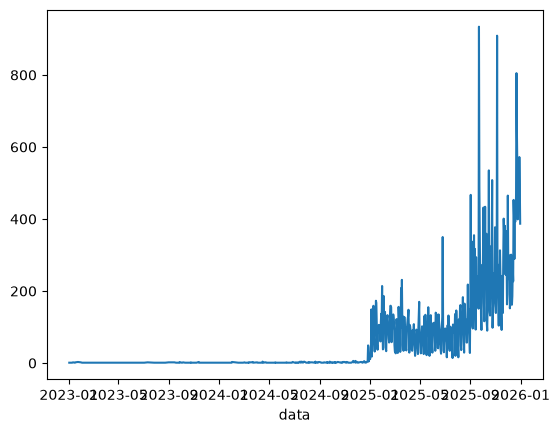

In [19]:
# Visualizando em um gráfico a quantidade de incidentes por dia
plt.figure(figsize=(12,6))
incidentes_dt.plot(legend=False, x='data')

In [20]:
# Criando uma cópia do DataFrame incidentes_dt para manipulação
df_inc2 = incidentes_dt.copy()

In [21]:
# Fazendo um corte nos dados a partir do índice 238 que são mais recentes e significativos
df_inc2 = df_inc2[238:]

In [22]:
df_inc2.shape

(370, 2)

<Axes: xlabel='data'>

<Figure size 1200x600 with 0 Axes>

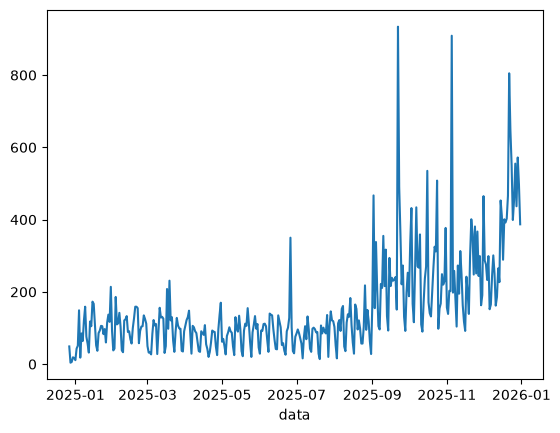

In [23]:
# Visualizado os dados com o corte realizado
plt.figure(figsize=(12,6))
df_inc2.plot(legend=False, x='data')

# Modelagem ARIMA

In [24]:
# Colocando a data como índice para utilizar em modelos de séries temporais
df_inc2.set_index('data', drop=True, inplace=True)

In [25]:
df_inc2.head(10)

,qtd_incidentes
data,
2024-12-27,49
2024-12-28,4
2024-12-29,6
2024-12-30,19
2024-12-31,17
2025-01-01,11
2025-01-02,43
2025-01-03,51
2025-01-04,149


## Verificando estacionariedade

In [ ]:
# Adfuller
teste_adf = adfuller(df_inc2)
print(f'Estatistica ADF: {teste_adf[0]:.4f}')
print(f'p-valor: {teste_adf[1]:.4f}')

if teste_adf[1] < 0.05:
    print("Rejeitamos a hipótese nula de que a série temporal possui raiz unitária (não estacionária). Portanto, concluímos que a série é estacionária.")
else:
    print("Não rejeitamos a hipótese nula, ou seja, não há evidências suficientes para afirmar que a série é estacionária.")


Estatistica ADF: 0.6133
p-valor: 0.9879
Não rejeitamos a hipótese nula, ou seja, não há evidências suficientes para afirmar que a série é estacionária.


## Integrated (d)

In [ ]:
## Tecnica das primeiras diferencas

teste_adf = adfuller(df_inc2['qtd_incidentes'].diff().dropna())
print(f'Estatistica ADF: {teste_adf[0]:.4f}')
print(f'p-valor: {teste_adf[1]:.4f}')

if teste_adf[1] < 0.05:
    print("Rejeitamos a hipótese nula de que a série temporal possui raiz unitária (não estacionária). Portanto, concluímos que a série é estacionária.")
else:
    print("Não rejeitamos a hipótese nula, ou seja, não há evidências suficientes para afirmar que a série é estacionária.")

Estatistica ADF: -9.1402
p-valor: 0.0000
Rejeitamos a hipótese nula de que a série temporal possui raiz unitária (não estacionária). Portanto, concluímos que a série é estacionária.


<Axes: xlabel='data'>

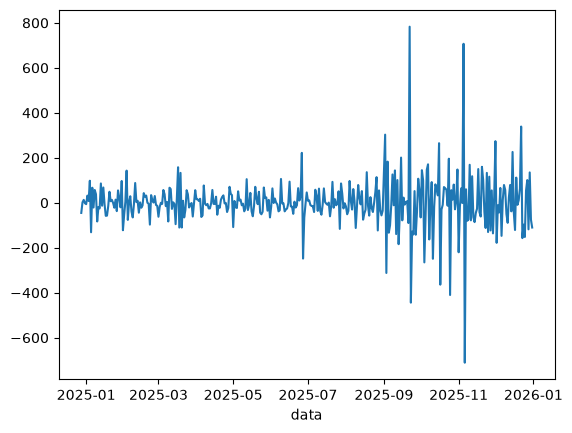

In [28]:
df_inc2['qtd_incidentes'].diff().dropna().plot(legend=False)

## PACF

In [29]:
df_inc2.shape

(370, 1)

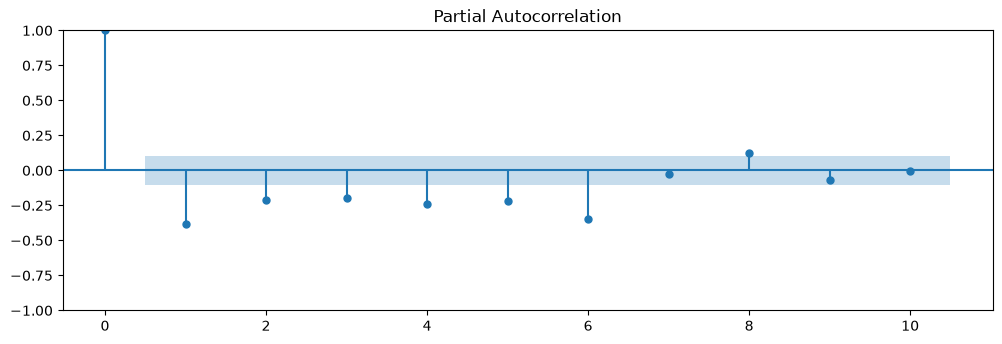

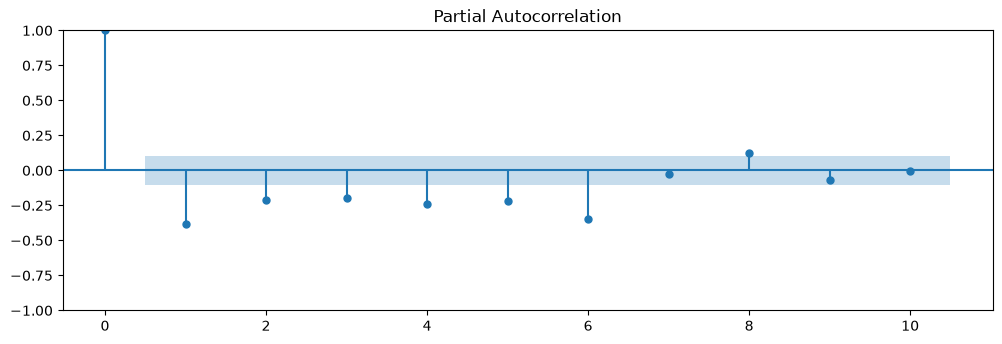

In [30]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
plot_pacf(df_inc2['qtd_incidentes'].diff().dropna(), lags= 10, ax= ax1)

## ACF

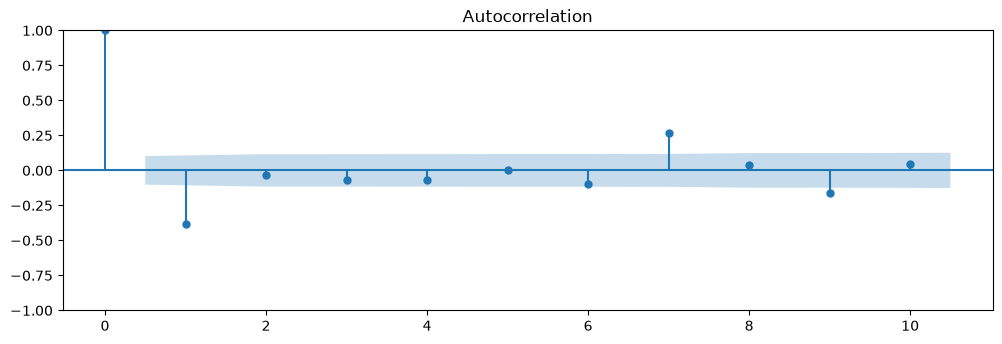

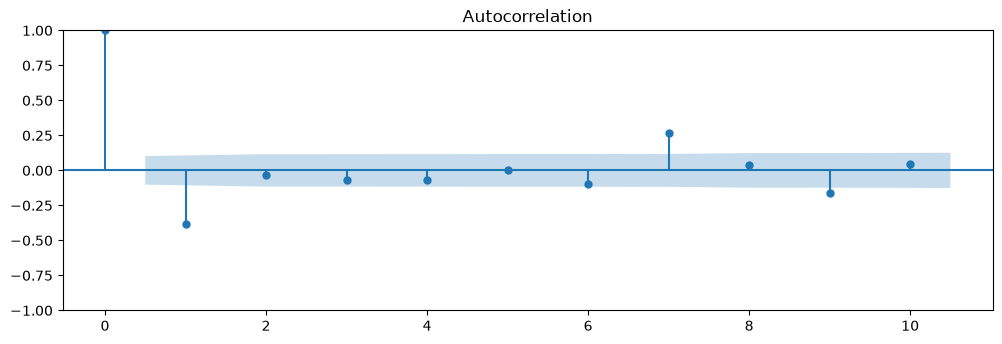

In [31]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
plot_acf(df_inc2['qtd_incidentes'].diff().dropna(), lags= 10, ax= ax1)

## Divisão Teste e Treino

In [32]:
df_inc2.shape

(370, 1)

In [33]:
tam_teste = 30
treino = df_inc2[:-tam_teste]
teste = df_inc2[-tam_teste:]

print(f"Dados de treino: {len(treino)} dias")
print(f"Dados de teste: {len(teste)} dias")

Dados de treino: 340 dias
Dados de teste: 30 dias


In [34]:
treino

,qtd_incidentes
data,
2024-12-27,49
2024-12-28,4
2024-12-29,6
2024-12-30,19
2024-12-31,17
...,...
2025-11-27,244
2025-11-28,299
2025-11-29,163


In [35]:
teste

,qtd_incidentes
data,
2025-12-02,287
2025-12-03,276
2025-12-04,233
2025-12-05,299
2025-12-06,152
2025-12-07,165
2025-12-08,244
2025-12-09,301
2025-12-10,251


## ARIMA(7,1,6)

In [36]:
## Preparando a Validacao Walk-Forward

historico = list(treino['qtd_incidentes'])
previsoes_d1 = []
valores_reais = list(teste['qtd_incidentes'])

print("\n Iniciandop as previsoes de D+1 (Walk-Forward)...")

for t in range(len(teste)):
    modelo = arima_7_1_6 = ARIMA(df_inc2['qtd_incidentes'], order = (7,1,6),)
    modelo_fit = modelo.fit()
    
    yhat = modelo_fit.forecast()
    previsoes_d1.append(yhat)
    
    valor_real = valores_reais[t]
    historico.append(valor_real)
    #print(f"Dia {t+1}: Previsto={yhat:.1f}, Real={valor_real}")


 Iniciandop as previsoes de D+1 (Walk-Forward)...


## Avaliacao de Performance da Baseline


--- Performance da Baseline ARIMA(7,1,6) ---
MAE (Erro Médio Absoluto): 126.87 incidentes
RMSE (Raiz do Erro Quadrático Médio): 157.50 incidentes


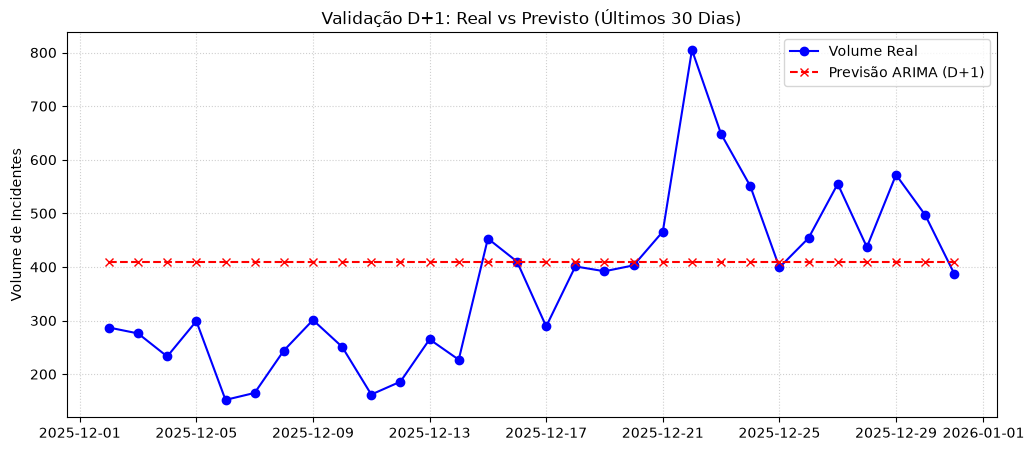

In [37]:
mae = mean_absolute_error(valores_reais, previsoes_d1)
rmse = np.sqrt(mean_squared_error(valores_reais, previsoes_d1))

print("\n--- Performance da Baseline ARIMA(7,1,6) ---")
print(f"MAE (Erro Médio Absoluto): {mae:.2f} incidentes")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f} incidentes")

# 4. Plotando o resultado para o PPT da Sprint 3
plt.figure(figsize=(12, 5))
plt.plot(teste.index, valores_reais, label='Volume Real', color='blue', marker='o')
plt.plot(teste.index, previsoes_d1, label='Previsão ARIMA (D+1)', color='red', linestyle='--', marker='x')
plt.title("Validação D+1: Real vs Previsto (Últimos 30 Dias)")
plt.ylabel("Volume de Incidentes")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Até aqui, encontramos um problema: tentamos modelar a série univariada com um ARIMA clássico e encontramos uma limitação. Devido à alta volatilidade e ausência de sazonalidade semanal no modelo univariado rígido, a baseline gerou uma predição constante com um MAE alto.

Para capturar os picos de volume que acontecem em dias específicos e o impacto das outras variáveis do Dicionário de Dados, vamos evoluir para um modelo baseado em árvores (como o XGBoost com lags) ou Prophet.

> Começamos com o ARIMA como linha de base por conta conteúdo disponibilizado na FIAP sobre séries temporais que aproveitamos para aplicar aqui.

# Ponderação sobre outros Modelos

Pesquisamos alguns modelos e encontramos o SARIMAX, XGBoost/LightGBM e Prophet.

1. O SARIMAX é excelente para poucas variáveis exógenas numéricas (ex: temperatura, taxa de juros), mas se tentarmos inputar dezenas de colunas categóricas (como o volume de incidentes do Team14 na Categoria X) em um SARIMAX, ele sofrerá com a "maldição da dimensionalidade". Os cálculos matemáticos do ARIMA ficam extremamente lentos e complexos com muitas variáveis.

2. A Força das Árvores (XGBoost / LightGBM): Com o nível de granularidade do dicionário, modelos de Gradient Boosting (como XGBoost) brilham. Eles não se importam se a série é estacionária ou não, e lidam incrivelmente bem com centenas de colunas de contagem agrupadas (lags). Para prever a sobrecarga de um time específico ou a quebra de KPI de um produto, o XGBoost supera o SARIMAX na maioria dos cenários do mundo real de ITSM.

3. A Simplicidade e Interpretabilidade do Prophet: Desenvolvido pelo Facebook (Meta), o Prophet foi projetado especificamente para séries temporais de negócios. Seu grande diferencial é a facilidade de capturar tendências, sazonalidades (diárias, semanais, mensais e anuais) e efeitos de feriados com pouca necessidade de ajuste manual. Em cenários onde o histórico da demanda possui padrões sazonais claros e a explicabilidade do resultado é importante para o negócio, o Prophet pode entregar previsões consistentes com baixo esforço de implementação.

# Vamos testar o Prophet

In [38]:
# Resetamos o índice para que a coluna de datas seja reconhecida pelo Prophet
df_prophet = df_inc2.reset_index()
df_prophet

,data,qtd_incidentes
0,2024-12-27,49
1,2024-12-28,4
2,2024-12-29,6
3,2024-12-30,19
4,2024-12-31,17
...,...,...
365,2025-12-27,555
366,2025-12-28,437
367,2025-12-29,572
368,2025-12-30,497


In [39]:
# Renomeando as colunas para o formato esperado pelo Prophet
df_prophet = df_prophet[['data', 'qtd_incidentes']]
df_prophet.columns = ['ds', 'y']

In [40]:
df_prophet.columns

Index(['ds', 'y'], dtype='str')

## Separando Treino e Teste 

In [41]:
tam_teste = 30
train = df_prophet.iloc[:-tam_teste]
test = df_prophet.iloc[-tam_teste:]

print("Iniciando o treinamento do Prophet...")


Iniciando o treinamento do Prophet...


In [42]:
# Criando o modelo
modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

modelo_prophet.add_country_holidays(country_name='BR')

In [43]:
# Treinamento o modelo
modelo_prophet.fit(train)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
22:41:50 - cmdstanpy - INFO - Chain [1] start processing
22:41:51 - cmdstanpy - INFO - Chain [1] done processing


In [44]:
# Prevendo o futuro
futuro = modelo_prophet.make_future_dataframe(periods=tam_teste, freq='D')

In [45]:
# Criando um df com as previsoes
previsao = modelo_prophet.predict(futuro)

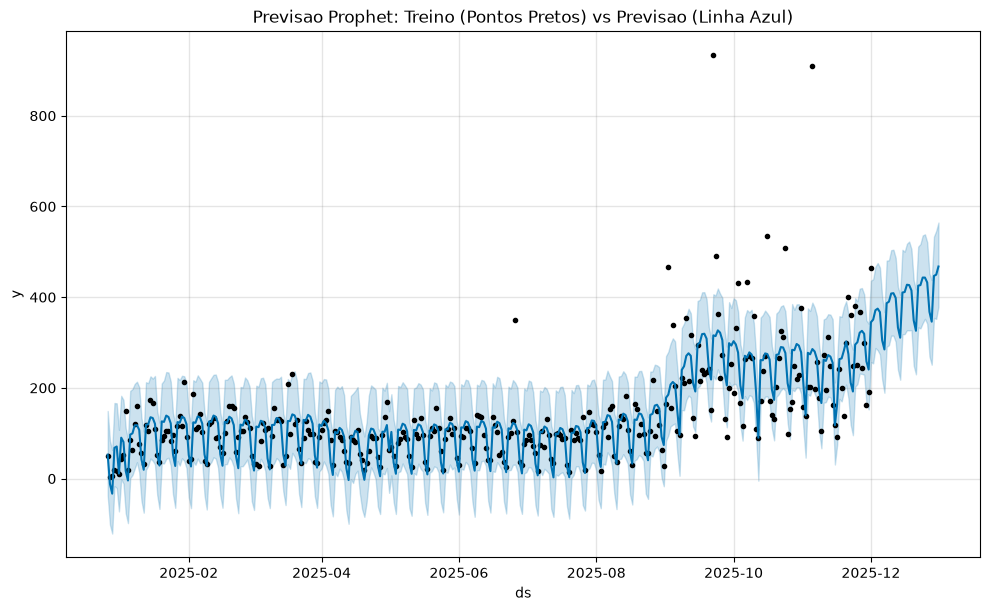

In [46]:
# Visualizando as previsões do Prophet
fig1 = modelo_prophet.plot(previsao)
plt.title('Previsao Prophet: Treino (Pontos Pretos) vs Previsao (Linha Azul)')
plt.show()

In [47]:
# Criando as séries para comparação
previsoes_teste = previsao.iloc[-tam_teste:]['yhat'].values

In [48]:
valores_reais = test['y'].values

In [ ]:
# Verificando a performance do modelo Prophet
mae = mean_absolute_error(valores_reais, previsoes_teste) # pyright: ignore[reportArgumentType]
rmse = np.sqrt(mean_squared_error(valores_reais, previsoes_teste))  # pyright: ignore[reportArgumentType]

print("\n--- Performance do Modelo Prophet ---")
print(f"MAE (Erro Médio Absoluto): {mae:.2f} incidentes")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f} incidentes")


--- Performance do Modelo Prophet ---
MAE (Erro Médio Absoluto): 112.40 incidentes
RMSE (Raiz do Erro Quadrático Médio): 137.32 incidentes


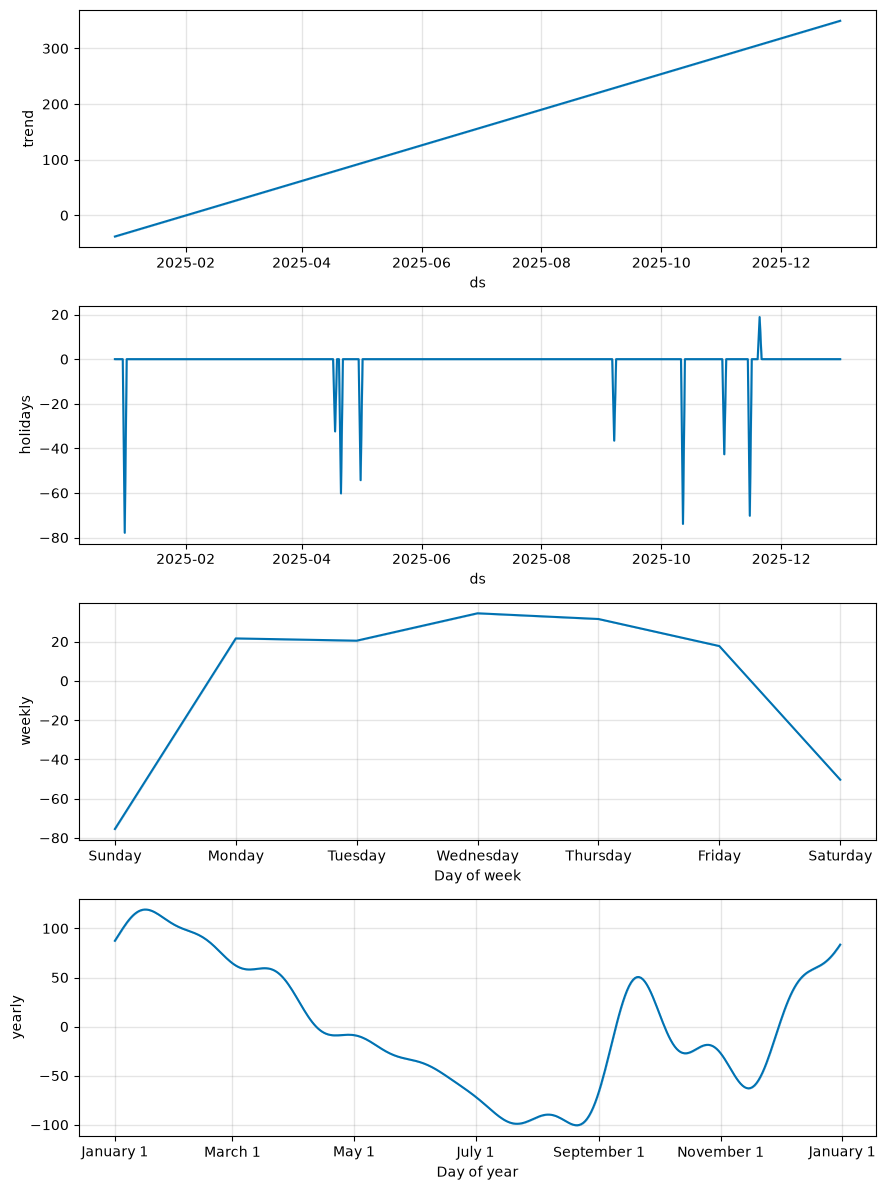

In [50]:
# Com o Prophet, podemos visualizar os componentes da série temporal, como tendência, sazonalidade e feriados. Isso nos ajuda a entender melhor os padrões subjacentes nos dados.
fig2 = modelo_prophet.plot_components(previsao)
plt.show()

## Impacto de Outliers

Com base no gráfico das previsões, o motivo para os erros de MAE e RMSE continuarem altos está escancarado na distribuição dos pontos pretos (os dados reais). O dataset sofreu uma quebra estrutural massiva.

Podemos notar que entre janeiro e agosto, o volume diário flutuava de forma comportada em torno de 100 incidentes. De repente, a partir de setembro, o comportamento da operação mudou completamente: a média saltou para a casa dos 300 incidentes, com picos violentos (outliers) batendo quase 900 chamados em dias específicos (os dois pontos isolados no topo direito).

Os dois pontos isolados próximos a 900 estão explodindo o seu RMSE. O Prophet tenta traçar uma linha suave para entender a tendência anual, mas esse salto abrupto no final do ano "confunde" a matemática do modelo.

# Por isso:
Devemos fazer um Tratamento de Outliers (Clipping). Os dois dias com 900 chamados provavelmente foram instabilidades sistêmicas massivas (quedas de servidor, rompimentos de rede). Para uma previsão baseline de rotina, esses dias devem ser tratados. Iremos substituir qualquer volume acima do percentil 95 (ex: tudo acima de 500) pelo limite máximo aceitável, ancorando a variância do modelo.

In [51]:
limite_p95 = df_prophet['y'].quantile(0.95)
print(f"Limitando outliers acima de: {limite_p95:.0f} incidentes")

Limitando outliers acima de: 422 incidentes


In [52]:
df_prophet['y'] = np.clip(df_prophet['y'], a_min=None, a_max=limite_p95)

## Separando Treino e Teste 

In [53]:
tam_teste = 30
train = df_prophet.iloc[:-tam_teste]
test = df_prophet.iloc[-tam_teste:]

print("Iniciando o treinamento do Prophet...")


Iniciando o treinamento do Prophet...


In [54]:
modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

modelo_prophet.add_country_holidays(country_name='BR')

In [55]:
modelo_prophet.fit(train)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
22:41:52 - cmdstanpy - INFO - Chain [1] start processing
22:41:52 - cmdstanpy - INFO - Chain [1] done processing


In [56]:
futuro = modelo_prophet.make_future_dataframe(periods=tam_teste, freq='D')

In [57]:
previsao = modelo_prophet.predict(futuro)

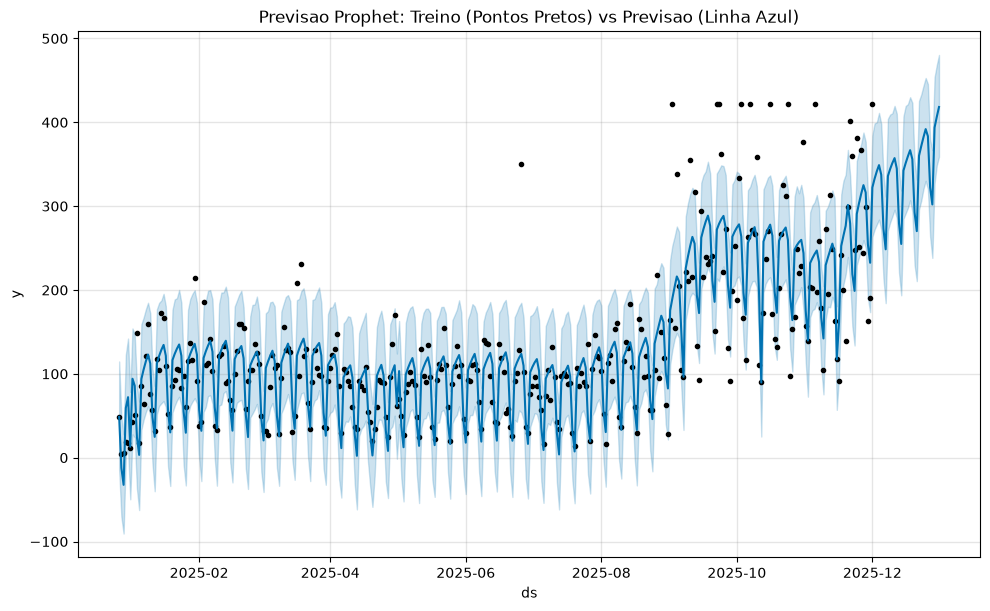

In [58]:
# Verificando o gráfico de previsão do Prophet após limitar os outliers

fig1 = modelo_prophet.plot(previsao)
plt.title('Previsao Prophet: Treino (Pontos Pretos) vs Previsao (Linha Azul)')
plt.show()

In [59]:
previsoes_teste = previsao.iloc[-tam_teste:]['yhat'].values

In [60]:
valores_reais = test['y'].values

In [ ]:
mae = mean_absolute_error(valores_reais, previsoes_teste) # pyright: ignore[reportArgumentType]
rmse = np.sqrt(mean_squared_error(valores_reais, previsoes_teste)) # pyright: ignore[reportArgumentType]

print("\n--- Performance do Modelo Prophet ---")
print(f"MAE (Erro Médio Absoluto): {mae:.2f} incidentes")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f} incidentes")


--- Performance do Modelo Prophet ---
MAE (Erro Médio Absoluto): 71.22 incidentes
RMSE (Raiz do Erro Quadrático Médio): 84.87 incidentes


# Conclusão

Tivemos uma melhora drástica nas métricas de erro e o Prophet se mostrou um bom modelo. No entanto, assim como o SARIMAX, o Prophet não foi concebido para trabalhar com centenas de variáveis explicativas de alta granularidade. Embora permita a inclusão de regressores externos, seu desempenho tende a ser inferior ao de modelos baseados em árvores quando o problema envolve um grande volume de atributos derivados de categorias, equipes, produtos ou tipos de incidentes. E como precisamos identificar quais categorias, equipes, e influência das variáveis sobre o volume de incidentes, o Prophet não conseguirá nos fornecer as informações. Dessa forma, o Prophet se posiciona como uma excelente opção para criar um baseline temporal robusto e interpretável, mas o XGBoost/LightGBM permanece mais adequado para explorar toda a riqueza de variáveis disponível no dicionário de dados do ITSM. Por conta disso, iremos testar mais modelos.

Seguimos com mais modelos em outro notebook: [XGBoost_KMeans.ipynb](XGBoost_KMeans.ipynb)